### Quellen für die Eigenschaften

Für diese Aminosäuren-Eigenschaften verwende ich meist standardisierte Tabellen aus der Literatur und Datenbanken:

#### Hydrophobizität (Kyte-Doolittle Skala)
Kyte, J., & Doolittle, R. F. (1982). A simple method for displaying the hydropathic character of a protein. Journal of Molecular Biology, 157(1), 105–132.
DOI: 10.1016/0022-2836(82)90515-0

#### Ladung (einfach: +1, -1, 0 je nach pH7)
(Standardannahme aus Biochemie-Lehrbüchern wie Nelson et al., Lehninger Principles of Biochemistry, 8th Edition)

#### Molekulargewicht (Durchschnittswert aus Uniprot, 2024, leicht gerundet)
(Basis: Monoisotopische Masse ohne Wasserstoff am N- und C-Terminus; Quelle: Uniprot)

#### Polarität (Grantham, 1974)
Grantham, R. (1974). Amino acid difference formula to help explain protein evolution. Science, 185(4154), 862–864.
DOI: 10.1126/science.185.4154.862

In [52]:
# Eigenschaften der AS in Dictionary anlegen


amino_acid_properties = {
    'A': {'hydrophobicity': 1.8, 'charge': 0, 'mass': 89.09, 'polarity': 8.1},
    'R': {'hydrophobicity': -4.5, 'charge': +1, 'mass': 174.20, 'polarity': 10.5},
    'N': {'hydrophobicity': -3.5, 'charge': 0, 'mass': 132.12, 'polarity': 11.6},
    'D': {'hydrophobicity': -3.5, 'charge': -1, 'mass': 133.10, 'polarity': 13.0},
    'C': {'hydrophobicity': 2.5, 'charge': 0, 'mass': 121.15, 'polarity': 5.5},
    'Q': {'hydrophobicity': -3.5, 'charge': 0, 'mass': 146.15, 'polarity': 10.5},
    'E': {'hydrophobicity': -3.5, 'charge': -1, 'mass': 147.13, 'polarity': 12.3},
    'G': {'hydrophobicity': -0.4, 'charge': 0, 'mass': 75.07, 'polarity': 9.0},
    'H': {'hydrophobicity': -3.2, 'charge': +1, 'mass': 155.16, 'polarity': 10.4},
    'I': {'hydrophobicity': 4.5, 'charge': 0, 'mass': 131.17, 'polarity': 5.2},
    'L': {'hydrophobicity': 3.8, 'charge': 0, 'mass': 131.17, 'polarity': 4.9},
    'K': {'hydrophobicity': -3.9, 'charge': +1, 'mass': 146.19, 'polarity': 11.3},
    'M': {'hydrophobicity': 1.9, 'charge': 0, 'mass': 149.21, 'polarity': 5.7},
    'F': {'hydrophobicity': 2.8, 'charge': 0, 'mass': 165.19, 'polarity': 5.2},
    'P': {'hydrophobicity': -1.6, 'charge': 0, 'mass': 115.13, 'polarity': 8.0},
    'S': {'hydrophobicity': -0.8, 'charge': 0, 'mass': 105.09, 'polarity': 9.2},
    'T': {'hydrophobicity': -0.7, 'charge': 0, 'mass': 119.12, 'polarity': 8.6},
    'W': {'hydrophobicity': -0.9, 'charge': 0, 'mass': 204.23, 'polarity': 5.4},
    'Y': {'hydrophobicity': -1.3, 'charge': 0, 'mass': 181.19, 'polarity': 6.2},
    'V': {'hydrophobicity': 4.2, 'charge': 0, 'mass': 117.15, 'polarity': 5.9}
}

In [53]:
import pandas as pd 
df = pd.read_csv("sars_cov2_cdrh3.tsv", sep="\t")
print(df.isna().sum())

#Nur Zeilen mit fehlenden Sequenzen in CDR_H3 entfernen:
df = df[df["CDR_H3"].notna()]
#überprüfen 
print(df.isna().sum())




pdb            0
heavy_chain    0
CDR_H3         1
dtype: int64
pdb            0
heavy_chain    0
CDR_H3         0
dtype: int64


### Tests die wir durchführen können:

1. Aminosäure-Häufigkeiten: Zählen, wie oft jede Aminosäure in jeder CDR H3 vorkommt.

2. Hydrophobizität, Ladung und Polarität: Mittlere Werte pro Sequenz.

3. Längenverteilung der CDR H3: Wie lang sind die Schleifen?

4. PCA: Dimensionen reduzieren und Cluster visualisieren.

5. Hierarchisches Clustering: Ähnliche Sequenzen gruppieren.

6. T-Test: Vergleiche zwischen Gruppen 

In [54]:
import pandas as pd 
df = pd.read_csv("sars_cov2_cdrh3.tsv", sep="\t")

# 1.Aminosäure-Häufigkeiten: Zählen, wie oft jede Aminosäure in jeder CDR H3 vorkommt.


# keys (Buchstaben) aus Dictionary holen = Aminosäure-Liste erstellen
# amino_acid_properties ist dein Dictionary.
# .keys() holt alle Buchstaben ('A', 'R', 'N' usw.).
# list(...) macht daraus eine Liste
amino_acids = list(amino_acid_properties.keys()) 

# für jede Sequenz alle Aminosäuren zählen
# df.iterrows() geht jede Zeile durch.
# row["CDR_H3"] holt die Sequenz der aktuellen Zeile.
# index ist die Zeilennummer (0-basiert)
for index, row in df.iterrows():
    sequence = row["CDR_H3"]
    print(f"Sequenz {index+1}: {sequence}")

# AS zählen
    if isinstance(sequence, str):
        for aa in amino_acids:
            count = sequence.count(aa)
            print(f"  - {aa}: {count}")
            df.loc[index, f'count_{aa}'] = count
    else:
        print(f"Warnung: Zeile {index} hat keine gültige Sequenz. (Typ: {type(sequence)})")

        
        # Ausgabe: Zeige die ersten Zeilen mit den neuen Spalten
print(df.head())

Sequenz 1: TFGTYYDNTEDWFFDF
  - A: 0
  - R: 0
  - N: 1
  - D: 3
  - C: 0
  - Q: 0
  - E: 1
  - G: 1
  - H: 0
  - I: 0
  - L: 0
  - K: 0
  - M: 0
  - F: 4
  - P: 0
  - S: 0
  - T: 3
  - W: 1
  - Y: 2
  - V: 0
Sequenz 2: LPLGERIDY
  - A: 0
  - R: 1
  - N: 0
  - D: 1
  - C: 0
  - Q: 0
  - E: 1
  - G: 1
  - H: 0
  - I: 1
  - L: 2
  - K: 0
  - M: 0
  - F: 0
  - P: 1
  - S: 0
  - T: 0
  - W: 0
  - Y: 1
  - V: 0
Sequenz 3: HNGDPYDFWSGYNTWAGGLDV
  - A: 1
  - R: 0
  - N: 2
  - D: 3
  - C: 0
  - Q: 0
  - E: 0
  - G: 4
  - H: 1
  - I: 0
  - L: 1
  - K: 0
  - M: 0
  - F: 1
  - P: 1
  - S: 1
  - T: 1
  - W: 2
  - Y: 2
  - V: 1
Sequenz 4: QGDLGDWILLGY
  - A: 0
  - R: 0
  - N: 0
  - D: 2
  - C: 0
  - Q: 1
  - E: 0
  - G: 3
  - H: 0
  - I: 1
  - L: 3
  - K: 0
  - M: 0
  - F: 0
  - P: 0
  - S: 0
  - T: 0
  - W: 1
  - Y: 1
  - V: 0
Sequenz 5: QGDLGDWILLGY
  - A: 0
  - R: 0
  - N: 0
  - D: 2
  - C: 0
  - Q: 1
  - E: 0
  - G: 3
  - H: 0
  - I: 1
  - L: 3
  - K: 0
  - M: 0
  - F: 0
  - P: 0
  - S: 0
  - T:

In [55]:
# 2.Hydrophobizität, Ladung und Polarität: Mittlere Werte pro Sequenz

# Schleife, um jede Sequenz durchzugehen. Für jede Aminosäure holen wir uns aus deinem Dictionary die Eigenschaft und bilden dann den Mittelwert
# = Berechne mittlere Hydrophobizität, Ladung und Polarität pro Sequenz

# Gehe jede Zeile durch
for index, row in df.iterrows():
    sequence = row["CDR_H3"]

    # Listen für die Werte
    hydrophobicities = []
    charges = []
    polarities = []
    masses = []

    # Gehe jede Aminosäure durch
    for aa in sequence:
        if aa in amino_acid_properties:
            hydrophobicities.append(amino_acid_properties[aa]['hydrophobicity'])
            charges.append(amino_acid_properties[aa]['charge'])
            polarities.append(amino_acid_properties[aa]['polarity'])
            masses.append(amino_acid_properties[aa]['mass'])
        else:
            print(f"Warnung: Unbekannte Aminosäure '{aa}' in Sequenz {index+1}")

    # Berechne die Mittelwerte (nur falls Listen nicht leer)
    if hydrophobicities:
        mean_hydrophobicity = sum(hydrophobicities) / len(hydrophobicities)
        df.loc[index, 'mean_hydrophobicity'] = mean_hydrophobicity

    if charges:
        mean_charge = sum(charges) / len(charges)
        df.loc[index, 'mean_charge'] = mean_charge

    if polarities:
        mean_polarity = sum(polarities) / len(polarities)
        df.loc[index, 'mean_polarity'] = mean_polarity

    if masses:
        mean_mass = sum(masses) / len(masses)
        df.loc[index, 'mean_mass'] = mean_mass
        

# Erklärungen 
#for index, row in df.iterrows(): = Wir gehen jede Zeile (jede Sequenz) durch.

# sequence = row["CDR_H3"] = Hol dir die aktuelle Sequenz.

# hydrophobicities, charges, polarities = [] = Leere Listen zum Sammeln der Werte pro Aminosäure.

# for aa in sequence: = Gehe jede Aminosäure durch.

# amino_acid_properties[aa]['hydrophobicity'] = Hol den Hydrophobizitätswert der Aminosäure.

# sum(hydrophobicities) / len(hydrophobicities) = Berechne den Mittelwert.

# df.loc[index, 'mean_hydrophobicity'] = ... = Speichere den Wert direkt im DataFrame
          


TypeError: 'float' object is not iterable

In [56]:
for index, row in df.iterrows():
    sequence = row["CDR_H3"]

    if isinstance(sequence, str):
        # Listen für die Werte
        hydrophobicities = []
        charges = []
        polarities = []
        masses = []

        # Gehe jede Aminosäure durch
        for aa in sequence:
            if aa in amino_acid_properties:
                hydrophobicities.append(amino_acid_properties[aa]['hydrophobicity'])
                charges.append(amino_acid_properties[aa]['charge'])
                polarities.append(amino_acid_properties[aa]['polarity'])
                masses.append(amino_acid_properties[aa]['mass'])
            else:
                print(f"Warnung: Unbekannte Aminosäure '{aa}' in Sequenz {index+1}")

        # Berechne die Mittelwerte (nur falls Listen nicht leer)
        if hydrophobicities:
            mean_hydrophobicity = sum(hydrophobicities) / len(hydrophobicities)
            df.loc[index, 'mean_hydrophobicity'] = mean_hydrophobicity

        if charges:
            mean_charge = sum(charges) / len(charges)
            df.loc[index, 'mean_charge'] = mean_charge

        if polarities:
            mean_polarity = sum(polarities) / len(polarities)
            df.loc[index, 'mean_polarity'] = mean_polarity

        if masses:
            mean_mass = sum(masses) / len(masses)
            df.loc[index, 'mean_mass'] = mean_mass

    else:
        print(f"⚠️ Warnung: Zeile {index+1} enthält keine gültige Sequenz (Typ: {type(sequence)})")
print(df.head())

⚠️ Warnung: Zeile 162 enthält keine gültige Sequenz (Typ: <class 'float'>)
    pdb heavy_chain                 CDR_H3  count_A  count_R  count_N  \
0  9cci           B       TFGTYYDNTEDWFFDF      0.0      0.0      1.0   
1  9ccj           H              LPLGERIDY      0.0      1.0      0.0   
2  9bj2           H  HNGDPYDFWSGYNTWAGGLDV      1.0      0.0      2.0   
3  8z6r           E           QGDLGDWILLGY      0.0      0.0      0.0   
4  8z6s           E           QGDLGDWILLGY      0.0      0.0      0.0   

   count_D  count_C  count_Q  count_E  ...  count_P  count_S  count_T  \
0      3.0      0.0      0.0      1.0  ...      0.0      0.0      3.0   
1      1.0      0.0      0.0      1.0  ...      1.0      0.0      0.0   
2      3.0      0.0      0.0      0.0  ...      1.0      1.0      1.0   
3      2.0      0.0      1.0      0.0  ...      0.0      0.0      0.0   
4      2.0      0.0      1.0      0.0  ...      0.0      0.0      0.0   

   count_W  count_Y  count_V  mean_hydrophobici

In [57]:
# 3. Längenverteilung der CDR H3: Wie lang sind die Schleifen?

# Gehe jede Zeile durch
for index, row in df.iterrows():
    sequence = row["CDR_H3"]
    
    # Berechne die Länge der Sequenz
    length = len(sequence)
    
    # Speichere die Länge im DataFrame (nur lokal)
    df.loc[index, 'cdr_h3_length'] = length

    # Ausgabe zur Kontrolle
    print(f"Sequenz {index+1}: Länge = {length}")

    # um Daten in CSV-Datei zu speichern
    df.to_csv("cdr_h3_with_all_features.csv", index=False)

#df.to_csv(...) = exportiert dein DataFrame in eine CSV-Datei.
# "cdr_h3_with_all_features.csv" = der Dateiname
# index=False = Zeilennummern werden nicht als zusätzliche Spalte in die CSV-Datei geschrieben

Sequenz 1: Länge = 16
Sequenz 2: Länge = 9
Sequenz 3: Länge = 21
Sequenz 4: Länge = 12
Sequenz 5: Länge = 12
Sequenz 6: Länge = 12
Sequenz 7: Länge = 12
Sequenz 8: Länge = 18
Sequenz 9: Länge = 13
Sequenz 10: Länge = 14
Sequenz 11: Länge = 18
Sequenz 12: Länge = 14
Sequenz 13: Länge = 18
Sequenz 14: Länge = 13
Sequenz 15: Länge = 14
Sequenz 16: Länge = 14
Sequenz 17: Länge = 14
Sequenz 18: Länge = 12
Sequenz 19: Länge = 18
Sequenz 20: Länge = 16
Sequenz 21: Länge = 8
Sequenz 22: Länge = 14
Sequenz 23: Länge = 17
Sequenz 24: Länge = 17
Sequenz 25: Länge = 13
Sequenz 26: Länge = 18
Sequenz 27: Länge = 9
Sequenz 28: Länge = 9
Sequenz 29: Länge = 9
Sequenz 30: Länge = 17
Sequenz 31: Länge = 11
Sequenz 32: Länge = 8
Sequenz 33: Länge = 9
Sequenz 34: Länge = 7
Sequenz 35: Länge = 9
Sequenz 36: Länge = 16
Sequenz 37: Länge = 16
Sequenz 38: Länge = 13
Sequenz 39: Länge = 14
Sequenz 40: Länge = 18
Sequenz 41: Länge = 13
Sequenz 42: Länge = 19
Sequenz 43: Länge = 19
Sequenz 44: Länge = 13
Sequen

TypeError: object of type 'float' has no len()

In [58]:
# 3. Längenverteilung der CDR H3: Wie lang sind die Schleifen?

# Gehe jede Zeile durch
for index, row in df.iterrows():
    sequence = row["CDR_H3"]
    
    if isinstance(sequence, str):
        # Berechne die Länge der Sequenz
        length = len(sequence)
        
        # Speichere die Länge im DataFrame (nur lokal)
        df.loc[index, 'cdr_h3_length'] = length

        # Ausgabe zur Kontrolle
        print(f"Sequenz {index+1}: Länge = {length}")
    else:
        print(f"⚠️ Warnung: Zeile {index+1} hat keine gültige Sequenz. (Typ: {type(sequence)})")

# Daten in CSV-Datei speichern
df.to_csv("cdr_h3_with_all_features.csv", index=False)


Sequenz 1: Länge = 16
Sequenz 2: Länge = 9
Sequenz 3: Länge = 21
Sequenz 4: Länge = 12
Sequenz 5: Länge = 12
Sequenz 6: Länge = 12
Sequenz 7: Länge = 12
Sequenz 8: Länge = 18
Sequenz 9: Länge = 13
Sequenz 10: Länge = 14
Sequenz 11: Länge = 18
Sequenz 12: Länge = 14
Sequenz 13: Länge = 18
Sequenz 14: Länge = 13
Sequenz 15: Länge = 14
Sequenz 16: Länge = 14
Sequenz 17: Länge = 14
Sequenz 18: Länge = 12
Sequenz 19: Länge = 18
Sequenz 20: Länge = 16
Sequenz 21: Länge = 8
Sequenz 22: Länge = 14
Sequenz 23: Länge = 17
Sequenz 24: Länge = 17
Sequenz 25: Länge = 13
Sequenz 26: Länge = 18
Sequenz 27: Länge = 9
Sequenz 28: Länge = 9
Sequenz 29: Länge = 9
Sequenz 30: Länge = 17
Sequenz 31: Länge = 11
Sequenz 32: Länge = 8
Sequenz 33: Länge = 9
Sequenz 34: Länge = 7
Sequenz 35: Länge = 9
Sequenz 36: Länge = 16
Sequenz 37: Länge = 16
Sequenz 38: Länge = 13
Sequenz 39: Länge = 14
Sequenz 40: Länge = 18
Sequenz 41: Länge = 13
Sequenz 42: Länge = 19
Sequenz 43: Länge = 19
Sequenz 44: Länge = 13
Sequen

In [59]:
print(df.head())

    pdb heavy_chain                 CDR_H3  count_A  count_R  count_N  \
0  9cci           B       TFGTYYDNTEDWFFDF      0.0      0.0      1.0   
1  9ccj           H              LPLGERIDY      0.0      1.0      0.0   
2  9bj2           H  HNGDPYDFWSGYNTWAGGLDV      1.0      0.0      2.0   
3  8z6r           E           QGDLGDWILLGY      0.0      0.0      0.0   
4  8z6s           E           QGDLGDWILLGY      0.0      0.0      0.0   

   count_D  count_C  count_Q  count_E  ...  count_S  count_T  count_W  \
0      3.0      0.0      0.0      1.0  ...      0.0      3.0      1.0   
1      1.0      0.0      0.0      1.0  ...      0.0      0.0      0.0   
2      3.0      0.0      0.0      0.0  ...      1.0      1.0      2.0   
3      2.0      0.0      1.0      0.0  ...      0.0      0.0      1.0   
4      2.0      0.0      1.0      0.0  ...      0.0      0.0      1.0   

   count_Y  count_V  mean_hydrophobicity  mean_charge  mean_polarity  \
0      2.0      0.0            -0.768750    -0.250

In [60]:
# Zählen, wie viele NaNs jede Spalte hat
print(df[pca_features].isna().sum())
print(df[pca_features].isna().any(axis=1).sum())

# Zeile mit NaN entfernen
df = df.dropna(subset=pca_features)




count_A                1
count_R                1
count_N                1
count_D                1
count_C                1
count_Q                1
count_E                1
count_G                1
count_H                1
count_I                1
count_L                1
count_K                1
count_M                1
count_F                1
count_P                1
count_S                1
count_T                1
count_W                1
count_Y                1
count_V                1
mean_hydrophobicity    1
mean_charge            1
mean_polarity          1
mean_mass              1
cdr_h3_length          1
dtype: int64
1


Features: ['count_A', 'count_R', 'count_N', 'count_D', 'count_C', 'count_Q', 'count_E', 'count_G', 'count_H', 'count_I', 'count_L', 'count_K', 'count_M', 'count_F', 'count_P', 'count_S', 'count_T', 'count_W', 'count_Y', 'count_V', 'mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass', 'cdr_h3_length']
PCA1-Gewichte: [ 0.03618069 -0.29349919 -0.22737511 -0.04240246 -0.1369478  -0.12544121
  0.04927614 -0.00694187 -0.19176395  0.03634838  0.1324246  -0.07503586
  0.19593103 -0.24084415 -0.19751185 -0.24036935 -0.07493604 -0.15837902
 -0.25326885  0.2103362   0.35697641 -0.31901958 -0.08764023 -0.279331
 -0.33710937]
PCA2-Gewichte: [ 0.29582216  0.12466704  0.13776409 -0.20292636  0.17913737 -0.05595051
 -0.03554632  0.14675316 -0.00904693  0.26716022  0.1404553  -0.0091433
  0.04153454  0.07961646  0.18188876  0.07400244  0.2073043   0.13973777
 -0.20896559  0.21821021  0.37776792  0.29629305 -0.30051829 -0.27461004
  0.30145151]


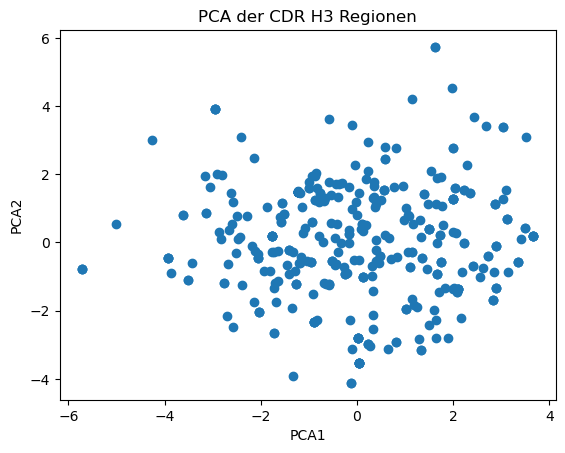

In [61]:
# 4. PCA: Dimensionen reduzieren und Cluster visualisieren

# Pakete importieren
# StandardScaler: Damit alle Features denselben Einfluss auf die PCA haben — sonst würden große Zahlen (z. B. Masse) die Analyse dominieren.
# PCA: Damit wir die Daten auf wenige Dimensionen reduzieren und Muster/Cluster erkennen können.
# matplotlib.pyplot: Damit wir die Ergebnisse schön als Plot darstellen können
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Features auswählen (Erstellen eine Liste mit allen Spaltennamen in df, beginnt mit dem Text 'count_')
# pca_features = ... anlegen neuer Variable namens pca_features (Darin abspeichern einer Liste mit Namen der Spalten, die wir für PCA verwenden)
# df.columns = Liste mit allen Spaltennamen des df
# if col.startswith('count_') = Prüfe, ob Spaltenname mit „count_“ anfängt
# [ ... ] = Spaltennamen, die Bedingung erfüllen, werden in Liste gepackt
# pca_features += ...= Kurzschreibweise um „Liste zu erweitern“ 
# +=  = bedeutet Liste pca_features wird um die Werte rechts von += ergänzt
pca_features = [col for col in df.columns if col.startswith('count_')]
pca_features += ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass', 'cdr_h3_length']

# Features skalieren
# scaler = selbstgewählter Variablenname; verwendet, um Skalierungsobjekt zu speichern.
# =: Zuweisungsoperator
# StandardScaler():  Aufruf der Klasse StandardScaler aus scikit-learn.
# StandardScaler = Klasse, die Daten transformiert: jede Spalte einen Mittelwert von 0 hat (zentriert) und eine Standardabweichung von 1 (normiert) hat.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[pca_features])

# PCA berechnen
# PCA(...): Aufruf der PCA-Klasse aus scikit-learn, die die Hauptkomponentenanalyse durchführt
#n_components: Parameter von PCA, der sagt:„Wie viele Hauptkomponenten möchtest du berechnen?“
# 2: Daten auf 2 Dimensionen reduzieren
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)


# Ergebnisse speichern
# df['PCA1'] = ...= Neue Spalte 'PCA1' im df, mit allen Werten aus PCA-Komponente
# pca_result[:, 0]=	Alle Zeilen, erste Spalte (PCA1) aus dem PCA-Ergebnis
# df['PCA2'] = ...	= Neue Spalte 'PCA2' im df , mit allen Werten aus der zweiten PCA-Komponente
#pca_result[:, 1]= Alle Zeilen, zweite Spalte (PCA2) aus dem PCA-Ergebnis
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]


# Features und Gewichte ausgeben
# print("Features:", pca_features)= Zeigt Namen der Features, die für die PCA verwendet wurden.
# pca.components_	= 2D-Array mit den Gewichten aller Features für jede Hauptkomponente.
# pca.components_[0]	Erste Zeile: Gewichte für PCA1.
# pca.components_[1]	Zweite Zeile: Gewichte für PCA2.
# print(...) =Gibt Infos in Konsole aus, damit du sehen kannst, welche Features wie stark wirken
print("Features:", pca_features)
print("PCA1-Gewichte:", pca.components_[0])
print("PCA2-Gewichte:", pca.components_[1])

# Scatter-Plot
#plt.scatter(...) = Erstellt einen Streudiagramm (Punktplot) mit PCA1 auf der X-Achse und PCA2 auf der Y-Achse.
# plt.xlabel(...)	= Beschriftet die X-Achse mit „PCA1“.
# plt.ylabel(...)	= Beschriftet die Y-Achse mit „PCA2“.
# plt.title(...) =	Gibt dem Plot einen Titel, damit du weißt, was er zeigt.
# plt.show()	= Zeigt den Plot auf dem Bildschirm an
plt.scatter(df['PCA1'], df['PCA2'])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('PCA der CDR H3 Regionen')
plt.show()

Was sagt mir die Analyse jetzt?

👉 Mit dem Scatter-Plot kannst du:

- Cluster oder Gruppen erkennen:
Wenn Punkte eng beieinanderliegen, sind sich diese Sequenzen im Muster ihrer Features (Counts, Mittelwerte etc.) ähnlich.

- Ausreißer erkennen:
Punkte, die weit abseits liegen, zeigen Sequenzen, die sehr speziell sind (z. B. viele oder wenige bestimmte Aminosäuren).

- Ähnliche Sequenzen vergleichen:
Wenn bestimmte Sequenzen ähnliche PCA-Werte haben, dann haben sie ähnliche Eigenschaften (Counts, Mittelwerte etc.)

In [ ]:
# 5. Hierarchisches Clustering anhand der PCA : Ähnliche Sequenzen gruppieren

# Pakete importieren
# scipy.cluster.hierarchy: Modul für hierarchisches Clustering in Python.
# linkage: Berechnet die Hierarchie (also welche Sequenzen wie ähnlich sind).
# dendrogram: Zeichnet das Baumdiagramm
from scipy.cluster.hierarchy import linkage, dendrogram

# Daten auswählen für das Clustering (PCA1 und PCA2 Werte aus unserem df)
# df[['PCA1', 'PCA2']]: Holt Spalten PCA1 und PCA2 aus dem DataFrame
# .values: Wandelt Daten in ein 2D-Array um —> Format, das linkage erwartet
cluster_data = df[['PCA1', 'PCA2']].values

# Hierarchisches Clustering berechnen
# linkage: Berechnet die Hierarchie (also wie ähnlich sich die Sequenzen sind).
# cluster_data: Unsere Datenpunkte (jeweils mit PCA1 und PCA2).
# method='ward': Methode, die die Cluster so zusammenfasst, dass die Unterschiede innerhalb der Cluster möglichst klein bleiben.
# Z = enthält Informationen, die für das Dendrogramm nötig sind
Z = linkage(cluster_data, method='ward')

# Dendrogramm plotten
# Z: Das Clustering-Ergebnis.
# labels=df.index: Wir verwenden die Zeilennummern des DataFrames als Labels (du kannst hier auch Sequenznamen verwenden)
# dendrogram(Z, labels=df["pdb_code"], leaf_rotation=90)=	Zeichnet Dendrogramm mit den PDB-Codes als Labels (senkrecht gedreht).
# plt.title(...)= Gibt dem Plot einen Titel.
# plt.xlabel(...)	= Beschriftet die X-Achse 
# plt.ylabel(...)	Beschriftet die Y-Achse mit „Distanz“ (zeigt die Unterschiede zwischen Sequenzen an).
# plt.show()	Zeigt den Plot an
# leaf_rotation=90: Dreht die Labels, damit sie lesbarer sind
plt.figure(figsize=(10, 6))  # Fenstergröße neu Grafik 10x16 Zoll
dendrogram(Z, labels=df["pdb_code"], leaf_rotation=90)
plt.title('Hierarchisches Clustering der CDR H3 Regionen')
plt.xlabel('Sequenzindex')
plt.ylabel('Distanz')
plt.show()

KeyError: 'pdb_code'

<Figure size 1000x600 with 0 Axes>

Was sagt dir das Dendrogramm?

- wie ähnlich oder unterschiedlich deine Sequenzen sind — basierend auf den PCA1- und PCA2-Werten.

- Jede „Verzweigung“ im Baum zeigt eine Gruppe von Sequenzen, die sich ähneln.
- Je **kürzer** der vertikale Abstand zwischen zwei Ästen ist, desto ähnlicher sind sich die Sequenzen.
- Ein langer vertikaler Ast bedeutet, dass sich die Gruppen stark unterscheiden.

a) Cluster definieren

➡️ Du kannst das Dendrogramm „abschneiden“ und so Cluster definieren:

Z. B. zwei große Cluster, drei Cluster, vier Cluster … (je nach deinem Projekt).

Dafür kannst du `scipy` verwenden:

```python
from scipy.cluster.hierarchy import fcluster

# Cluster definieren (z. B. 3 Cluster)
cluster_labels = fcluster(Z, t=3, criterion='maxclust')
df['Cluster'] = cluster_labels
```

Jetzt steht in der Spalte `Cluster`, zu welchem Cluster jede Sequenz gehört.

 b) Statistische Analysen innerhalb der Cluster durchführen

- Sind die Sequenzen innerhalb eines Clusters besonders lang oder kurz?
- Unterscheiden sich Cluster in `mean_mass`, `mean_hydrophobicity`, etc.?
  -> Dazu könntest du wieder einen T-Test machen oder Boxplots erstellen.


c) Visualisieren

- Mit `sns.scatterplot` oder `matplotlib.pyplot.scatter` kannst du die Cluster farblich hervorheben:

  ```python
  import seaborn as sns

  sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
  plt.title('Cluster auf PCA1/PCA2')
  plt.show()
  ```
Damit kannst du direkt sehen, ob deine Cluster auch im PCA-Plot sichtbar sind.

d) Gruppen-Annotation

- Vielleicht kannst du die Cluster mit biologischen oder funktionellen Informationen verknüpfen:

-  Z. B. neutralisierende vs. nicht-neutralisierende Antikörper
-  Oder Herkunft (verschiedene PDB-Strukturen, Patientenproben etc.)






In [ ]:
# 6. T-Test: Vergleiche zwischen Gruppen 